In [1]:
# week 14 Module - Homework # 11 (NLP - the Natural Language Processing) STUDENT NAME: MZ KHALFAN

# ACTIVITY 1 & 2: Pick the DATASET, LOAD it into a DataFrame - I picked 3: Amazon, IMDb, and Yelp

# LOADING the DATASET

import pandas as pd # necessary library

df = pd.read_csv("combined_sentiment_dataset.csv")
print(df.head())


                                            sentence  label  source
0  So there is no way for me to plug it in here i...      0  amazon
1                        Good case, Excellent value.      1  amazon
2                             Great for the jawbone.      1  amazon
3  Tied to charger for conversations lasting more...      0  amazon
4                                  The mic is great.      1  amazon


In [2]:
# INSPECTING the DATASET

df.shape
print(df.shape)

df.info()
print(df.info())

df['label'].value_counts()
print(df['label'].value_counts())

df['source'].value_counts()
print(df['source'].value_counts())

df.columns
print(df.columns)

df.describe()
print(df.describe())


(2748, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentence  2748 non-null   object
 1   label     2748 non-null   int64 
 2   source    2748 non-null   object
dtypes: int64(1), object(2)
memory usage: 64.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentence  2748 non-null   object
 1   label     2748 non-null   int64 
 2   source    2748 non-null   object
dtypes: int64(1), object(2)
memory usage: 64.5+ KB
None
label
1    1386
0    1362
Name: count, dtype: int64
source
amazon    1000
yelp      1000
imdb       748
Name: count, dtype: int64
Index(['sentence', 'label', 'source'], dtype='object')
             label
count  2748.000000
mean      0.504367
std       0.500072
min       0.000000
25%       0

In [3]:
# PREPROCESSING the DATA

import re
import string # necessary libraries

def clean_text(text):
    text = str(text).lower()  # lowercase
    text = re.sub(r'\s+', ' ', text)  # remove extra spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation/numbers
    return text.strip()

# Applying Cleaning to a Dataset/Text

df['clean_text'] = df['sentence'].apply(clean_text)

df[['sentence', 'clean_text']].head()


,sentence,clean_text
0,So there is no way for me to plug it in here i...,so there is no way for me to plug it in here i...
1,"Good case, Excellent value.",good case excellent value
2,Great for the jawbone.,great for the jawbone
3,Tied to charger for conversations lasting more...,tied to charger for conversations lasting more...
4,The mic is great.,the mic is great


In [4]:
# removing "stopwords" and "short words" from the DATASET/Text

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    words = text.split()
    filtered_words = [
        word for word in words 
        if word not in ENGLISH_STOP_WORDS and len(word) > 2
    ]
    return " ".join(filtered_words)

# applying it to dataset
df['clean_text'] = df['clean_text'].apply(remove_stopwords)

# Check the Results
df[['sentence', 'clean_text']].head()


,sentence,clean_text
0,So there is no way for me to plug it in here i...,way plug unless converter
1,"Good case, Excellent value.",good case excellent value
2,Great for the jawbone.,great jawbone
3,Tied to charger for conversations lasting more...,tied charger conversations lasting minutesmajo...
4,The mic is great.,mic great


In [5]:
# SENTIMENT ANALYSIS USING VADER

# (i) installing VADER

!pip install vaderSentiment


In [6]:
# (ii) import and initialize ANALYZER

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()


In [7]:
# (iii) Get the Sentiment Score

def get_sentiment_score(text):
    score = analyzer.polarity_scores(text)
    return score['compound']

df['sentiment_score'] = df['clean_text'].apply(get_sentiment_score)


In [8]:
# (iv) Classifying Sentiments into Positive / Negative / Neutral

def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)


In [9]:
# verifying the Classification

df[['sentence', 'clean_text', 'sentiment_score', 'sentiment']].head(10)

# count each category...

# Count each category
df['sentiment'].value_counts()


sentiment
Positive    1419
Negative     685
Neutral      644
Name: count, dtype: int64

In [10]:
# COMMENTARY ON VADER & CLASSIFICATION

# the Sentiment was computed using VADER, which assigns a compound score between negative one -1 and positive one +1 
# these scores were categorized using standard thresholds (into the Positive, the Negative, and Neutral Sentiments).


In [11]:
# EMOTION CLASSIFICATION USING NRCLex

# (i) Installing NRCLex
!pip install nrclex

# (ii) Importing NRCLex
from nrclex import NRCLex

# (iii) Checking available NRCLex attributes
test_emotion = NRCLex("happy sad angry surprised afraid disgusting")
dir(test_emotion)


['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lexicon__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_word_affect',
 '_compute_top_emotions',
 '_resolve_lexicon',
 'load_raw_text',
 'load_token_list']

In [12]:
# COMMENTARY ON NRCLex ATTRIBUTE CHECK:

# After checking the available NRCLex attributes... 
# this version of NRCLex did not provide direct emotion score outputs such as raw_emotion_scores or affect_frequencies.
# therefore, for the emotion classification portion of the assignment, I will resort to a custom lexicon-based approach.
# this method classifies words into their emotional categories such as anger, disgust, fear, joy, sadness, and surprise.
# VADER is still being used separately for classification of sentiments into the Positives, the Negatives, and Neutral.


In [13]:
# EMOTION CLASSIFICATION USING A CUSTOM Lexicon-Based Approach

emotion_lexicon = {
    'joy': ['good', 'great', 'excellent', 'amazing', 'love', 'happy', 'wonderful', 'best', 'nice', 'awesome', 'perfect'],
    'anger': ['bad', 'terrible', 'awful', 'hate', 'worst', 'angry', 'annoying', 'poor'],
    'sadness': ['sad', 'disappointed', 'unhappy', 'boring', 'dull', 'waste'],
    'fear': ['scared', 'afraid', 'fear', 'worried', 'problem', 'issue', 'broken'],
    'surprise': ['surprised', 'amazed', 'shocked', 'unexpected', 'wow'],
    'disgust': ['disgusting', 'gross', 'nasty', 'dirty', 'horrible']
}


In [14]:
# (i) DEFINING the EMOTION FUNCTION

def classify_emotions(text):
    words = text.split()
    emotions = {emotion: 0 for emotion in emotion_lexicon}
    
    for word in words:
        for emotion, keywords in emotion_lexicon.items():
            if word in keywords:
                emotions[emotion] += 1
    
    return emotions


In [15]:
# (ii) APPLYING the EMOTION FUNCTION into a DATASET

df['emotions'] = df['clean_text'].apply(classify_emotions)

df[['sentence', 'clean_text', 'emotions']].head(10)


,sentence,clean_text,emotions
0,So there is no way for me to plug it in here i...,way plug unless converter,"{'joy': 0, 'anger': 0, 'sadness': 0, 'fear': 0..."
1,"Good case, Excellent value.",good case excellent value,"{'joy': 2, 'anger': 0, 'sadness': 0, 'fear': 0..."
2,Great for the jawbone.,great jawbone,"{'joy': 1, 'anger': 0, 'sadness': 0, 'fear': 0..."
3,Tied to charger for conversations lasting more...,tied charger conversations lasting minutesmajo...,"{'joy': 0, 'anger': 0, 'sadness': 0, 'fear': 0..."
4,The mic is great.,mic great,"{'joy': 1, 'anger': 0, 'sadness': 0, 'fear': 0..."
5,I have to jiggle the plug to get it to line up...,jiggle plug line right decent volume,"{'joy': 0, 'anger': 0, 'sadness': 0, 'fear': 0..."
6,If you have several dozen or several hundred c...,dozen contacts imagine fun sending,"{'joy': 0, 'anger': 0, 'sadness': 0, 'fear': 0..."
7,If you are Razr owner...you must have this!,razr owneryou,"{'joy': 0, 'anger': 0, 'sadness': 0, 'fear': 0..."
8,"Needless to say, I wasted my money.",needless say wasted money,"{'joy': 0, 'anger': 0, 'sadness': 0, 'fear': 0..."
9,What a waste of money and time!.,waste money time,"{'joy': 0, 'anger': 0, 'sadness': 1, 'fear': 0..."


In [16]:
# (iii) COUNTING the TOTAL EMOTIONS

from collections import Counter

emotion_counts = Counter()

for emotion_dict in df['emotions']:
    emotion_counts.update(emotion_dict)

emotion_counts


Counter({'joy': 797,
         'anger': 234,
         'sadness': 87,
         'disgust': 36,
         'fear': 25,
         'surprise': 13})

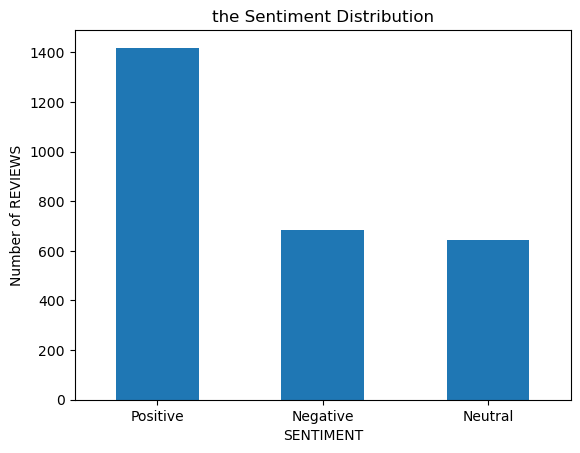

In [17]:
# VISUALIZING the SENTIMENTS and the EMOTIONS

# (i) SENTIMENT Bar Graph - Bar Graph for Sentiment Distribution

import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()

sentiment_counts.plot(kind='bar')
plt.title('the Sentiment Distribution')
plt.xlabel('SENTIMENT')
plt.ylabel('Number of REVIEWS')
plt.xticks(rotation=0)

plt.savefig("sentiment_distribution.png", bbox_inches='tight')
plt.show()


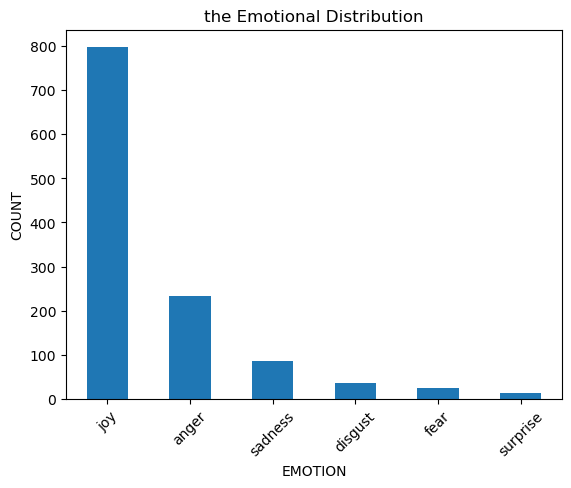

In [18]:
# (ii) EMOTIONS Bar Graph - Bar Graph for Emotion Distribution

emotion_df = pd.DataFrame(emotion_counts.items(), columns=['Emotion', 'Count'])
emotion_df = emotion_df.sort_values(by='Count', ascending=False)

emotion_df.plot(kind='bar', x='Emotion', y='Count', legend=False)
plt.title('the Emotional Distribution')
plt.xlabel('EMOTION')
plt.ylabel('COUNT')
plt.xticks(rotation=45)

plt.savefig("emotion_distribution.png", bbox_inches='tight')
plt.show()


In [19]:
# installing word cloud

!pip install wordcloud


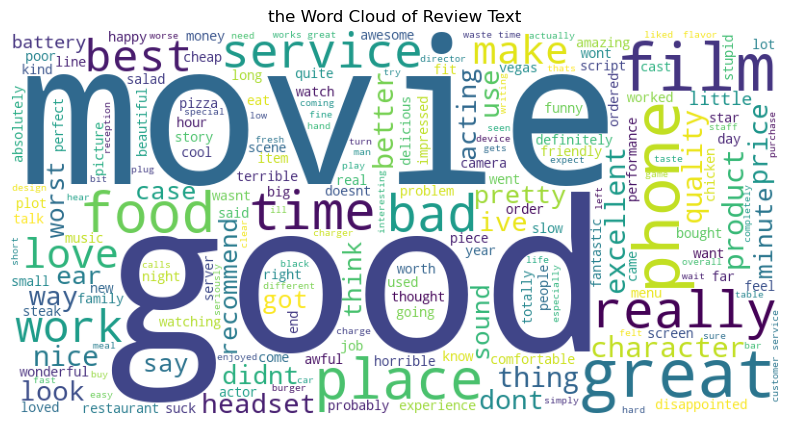

In [20]:
# (iii) the WORD CLOUD

from wordcloud import WordCloud

all_text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('the Word Cloud of Review Text')

plt.savefig("wordcloud.png", bbox_inches='tight')
plt.show()


In [21]:
# CONCLUSIONS Based on the Analysis:

# the Majority of Reviews are Positive (indicating over-all favorable user experiences)  
# “Joy” is the most dominant emotion (aligning with the positive sentiment results).  
# Negative Reviews are fewer but express stronger emotions such as anger and sadness  
# the Word Cloud highlights frequent positive terms like “good,” “great,” and “love”  
# Over-all, the Analysis shows that user feedback across domains is largely positive (with meaningful emotional patterns).


In [22]:
# FEATURE ENGINEERING (TF-IDF) - Term Frequency-Inverse Document Frequency

# Convert text into numerical features so Machine Learning Model can learn

# (i): import TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# (ii): define Features (X) and Target (y)
X = df['clean_text']   # input text
y = df['label']            # sentiment (0 or 1)

# (iii): apply TF-IDF
vectorizer = TfidfVectorizer()

X_tfidf = vectorizer.fit_transform(X)

# (iv): Check Shape
print(X_tfidf.shape)


(2748, 4971)


In [23]:
# SPLITTING THE DATASET INTO A TRAIN-TEST SPLIT

# (i): 80% Training - 20% Testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# (ii): Confirm Splitting
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# (iii): Check Label Balance
print("y_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())


Training set: (2198, 4971)
Test set: (550, 4971)
y_train distribution:
label
1    1109
0    1089
Name: count, dtype: int64

y_test distribution:
label
1    277
0    273
Name: count, dtype: int64


In [24]:
# MACHINE LEARNING MODEL BUILDING - Naive Bayes

# (i): import Model
from sklearn.naive_bayes import MultinomialNB

# (ii) train Model
model = MultinomialNB()
model.fit(X_train, y_train)

# (iii) make prediction
y_pred = model.predict(X_test)


Accuracy: 0.8072727272727273
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       273
           1       0.78      0.85      0.82       277

    accuracy                           0.81       550
   macro avg       0.81      0.81      0.81       550
weighted avg       0.81      0.81      0.81       550



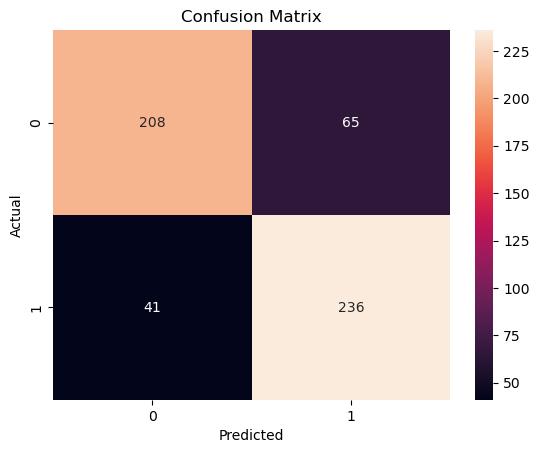

In [25]:
# MODEL EVALUATION - Naive Bayes

# (i): Accuracy
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

# (ii): Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

# (iii) Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", bbox_inches='tight')
plt.show()


In [26]:
# MODEL BUILDING — Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.7854545454545454


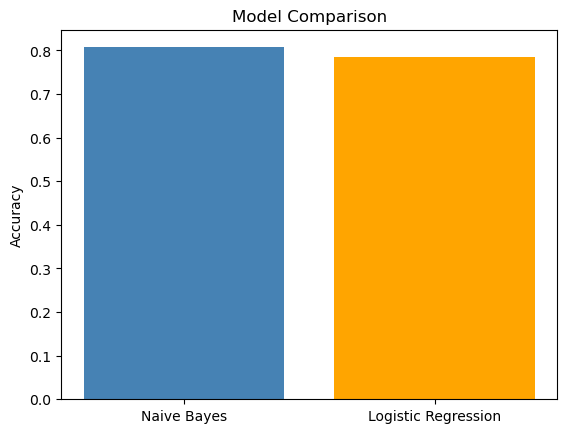

In [27]:
# MODEL COMPARISON — Naive Bayes vs. Logistic Regression

import matplotlib.pyplot as plt

models = ['Naive Bayes', 'Logistic Regression']
scores = [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_lr)]

plt.bar(models, scores, color=['steelblue', 'orange'])
plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.savefig("model_comparison.png", bbox_inches='tight')
plt.show()


In [28]:
# COMMENTARY ON THE MODEL COMPARISON

# the Naive Bayes model achieved a higher accuracy (~81%) compared to the Logistic Regression model (~79%). 
# this suggests that Naive Bayes is better suited for this text classification task...
# ... likely due to its effectiveness with high-dimensional TF-IDF features. 
# And while Logistic Regression also performed well, 
# Naive Bayes provided slightly more accurate predictions, making it the preferred model for this analysis.
